In [440]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

In [441]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score
from imblearn.over_sampling import SMOTE

In [442]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [443]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [444]:
(df==0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Checking for values with 0 

In [445]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0,np.nan)

In [446]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [447]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y)

In [448]:
train_median = X_train.median()
X_train.fillna(train_median,inplace=True)
X_test.fillna(train_median,inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
69,4,146.0,85.0,27.0,100.0,28.9,0.189,27
238,9,164.0,84.0,21.0,130.0,30.8,0.831,32
573,2,98.0,60.0,17.0,120.0,34.7,0.198,22
276,7,106.0,60.0,24.0,130.0,26.5,0.296,29
697,0,99.0,72.0,29.0,130.0,25.0,0.253,22
...,...,...,...,...,...,...,...,...
466,0,74.0,52.0,10.0,36.0,27.8,0.269,22
222,7,119.0,72.0,29.0,130.0,25.2,0.209,37
559,11,85.0,74.0,29.0,130.0,30.1,0.300,35
478,8,126.0,74.0,38.0,75.0,25.9,0.162,39


In [449]:
(df==0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [450]:
df['Insulin']

0        NaN
1        NaN
2        NaN
3       94.0
4      168.0
       ...  
763    180.0
764      NaN
765    112.0
766      NaN
767      NaN
Name: Insulin, Length: 768, dtype: float64

In [451]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# EDA
1) Data is slightly imbalanced so we prefer using precision, recall, F1 score
2) Insulin is higly skewed with extreme values

In [452]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

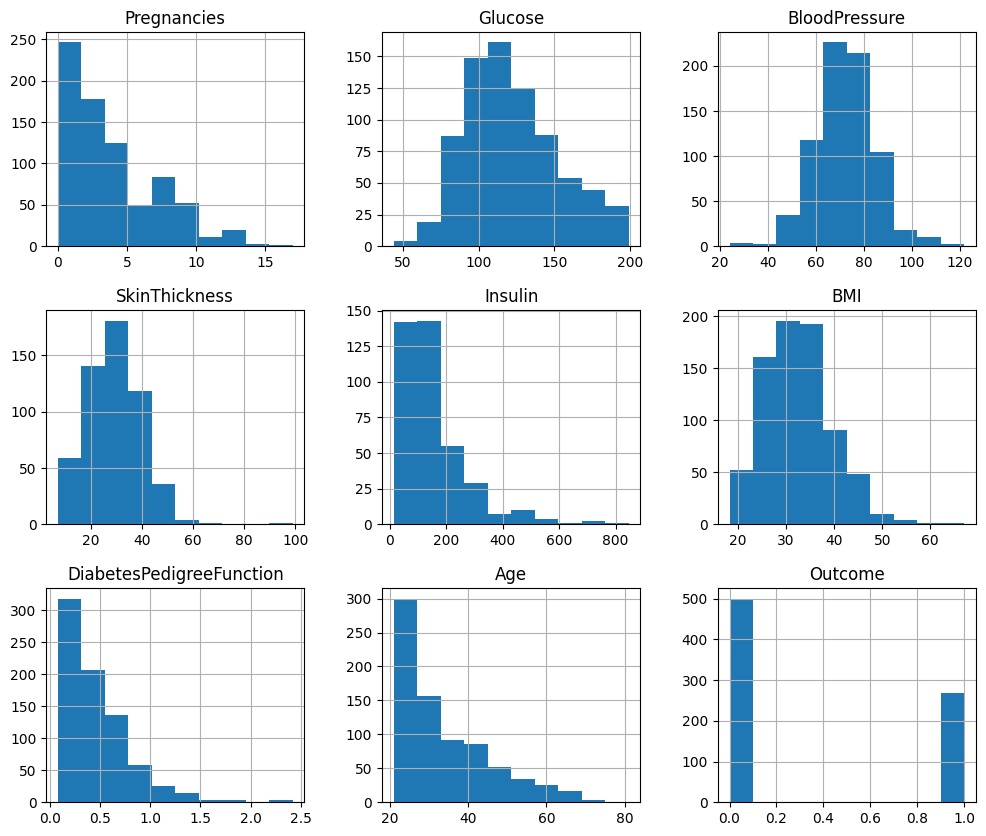

In [453]:
df.hist(figsize=(12,10))

Feature Selection

In [454]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128135,0.214178,0.100239,0.082171,0.021719,-0.033523,0.544341,0.221898
Glucose,0.128135,1.000000,0.223192,0.228043,0.581186,0.232771,0.137246,0.267136,0.494650
BloodPressure,0.214178,0.223192,1.000000,0.226839,0.098272,0.289230,-0.002805,0.330107,0.170589
SkinThickness,0.100239,0.228043,0.226839,1.000000,0.184888,0.648214,0.115016,0.166816,0.259491
Insulin,0.082171,0.581186,0.098272,0.184888,1.000000,0.228050,0.130395,0.220261,0.303454
BMI,0.021719,0.232771,0.289230,0.648214,0.228050,1.000000,0.155382,0.025841,0.313680
DiabetesPedigreeFunction,-0.033523,0.137246,-0.002805,0.115016,0.130395,0.155382,1.000000,0.033561,0.173844
Age,0.544341,0.267136,0.330107,0.166816,0.220261,0.025841,0.033561,1.000000,0.238356
Outcome,0.221898,0.494650,0.170589,0.259491,0.303454,0.313680,0.173844,0.238356,1.000000


In [455]:
df['BloodPressure'].corr(df['Outcome'])

np.float64(0.17058928446068464)

In [456]:
df.var()

Pregnancies                    11.354056
Glucose                       932.425376
BloodPressure                 153.317842
SkinThickness                 109.767160
Insulin                     14107.703775
BMI                            47.955463
DiabetesPedigreeFunction        0.109779
Age                           138.303046
Outcome                         0.227483
dtype: float64

In [457]:
mi_scores = mutual_info_classif(X_train,y_train)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values() 
drop_col = mi_series.index[0]
X_train.drop(drop_col, axis=1, inplace=True)
X_test.drop(drop_col, axis=1, inplace=True)

According to mutual info classif Blood Pressure and DiabetesPedigree Function has lowest rank

In [458]:
X_train

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age
631,0,102.0,78.0,90.0,34.5,0.238,24
49,7,105.0,72.0,130.0,32.3,0.305,24
298,14,100.0,78.0,184.0,36.6,0.412,46
74,1,79.0,75.0,130.0,32.0,0.396,22
90,1,80.0,55.0,130.0,19.1,0.258,21
...,...,...,...,...,...,...,...
516,9,145.0,88.0,165.0,30.3,0.771,53
189,5,139.0,80.0,160.0,31.6,0.361,25
338,9,152.0,78.0,171.0,34.2,0.893,33
553,1,88.0,62.0,44.0,29.9,0.422,23


Scaling data so Knn model works fine

In [459]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [460]:
sm = SMOTE()
X_train,y_train = sm.fit_resample(X_train,y_train)

In [461]:
from sklearn.model_selection import cross_val_score
best_k, best_score = 1,0

for k in range(1,27):
    knn = KNeighborsClassifier(k,weights='distance')
    score = cross_val_score(knn,X_train,y_train,cv=5,scoring='recall').mean()
    if score > best_score:
        best_score = score
        best_k = k 

print('best k', best_k)

best k 7


In [462]:
knn = KNeighborsClassifier(n_neighbors=best_k,weights='distance')
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
recall_score(y_test,y_pred)

0.7777777777777778

In [463]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.72      0.78       100
           1       0.60      0.78      0.68        54

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.74      0.75       154

